# 🎵 Listening to Extinction — Part 2
## AI Listens: How Does a Machine Hear a Bird?

> *Code Beyond the Earth | IDB 2026*

In Part 1, we mapped where Turkey's birds are moving geographically.  
In Part 2, we ask: **can a machine tell them apart by sound alone?**

### Pipeline:
1. Fetch audio URLs for all species with ≥10 recordings in Turkey
2. Extract 39-dimensional MFCC feature vectors per recording
3. Train a Random Forest classifier
4. Explain predictions with SHAP
5. Visualize: which acoustic features matter most?

### Input files (from Part 1):
- `turkey_birds_all.csv` — all 2,303 cleaned recordings
- `turkey_birds_shift_all.csv` — habitat shift summary

---

## 0. Setup

Install and import everything we need.  
`shap` is the key new addition here — it will let us explain the classifier's decisions.

In [1]:
!pip install requests pandas numpy matplotlib seaborn scikit-learn shap librosa soundfile --quiet

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import librosa
import shap
import io
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Visual style — consistent with Part 1
plt.style.use('dark_background')
COLORS = {
    'loser':  '#FF6B6B',
    'winner': '#6BFF9E',
    'silent': '#A8A8B3',
    'other':  '#30363D',
    'bg':     '#0D1117',
    'accent': '#58A6FF'
}

XC_API_KEY = ''  # your Xeno-canto API key

print('Setup complete.')

Setup complete.


## 1. Load Part 1 Data

We load the cleaned recordings from Part 1 and filter to species with **≥10 recordings**.  

Why 10? Below that, a classifier has too few examples per class to generalize.  
We also drop `Mystery mystery` — unidentified recordings that would add noise.

This gives us our **working species list** for Part 2.

In [2]:
# Load Part 1 output
df_all = pd.read_csv('turkey_birds_all.csv')
shift_all = pd.read_csv('turkey_birds_shift_all.csv')

# Species with enough recordings — minimum 10
MIN_RECORDS = 10
species_counts = df_all.groupby(['scientific_name', 'english_name']).size().reset_index(name='n')

# Drop unidentified recordings
species_counts = species_counts[~species_counts['scientific_name'].str.contains('Mystery', na=False)]

# Apply minimum threshold
valid_species = species_counts[species_counts['n'] >= MIN_RECORDS]
valid_species = valid_species.sort_values('n', ascending=False)

print(f'Species with ≥{MIN_RECORDS} recordings: {len(valid_species)}')
print(f'Total recordings in scope: {valid_species["n"].sum()}')
print()
print(f'{"Species":40} {"Recordings":>10}')
print('─' * 52)
for _, row in valid_species.iterrows():
    bar = '▪' * min(row['n'], 50)
    print(f"{row['english_name']:40} {row['n']:>5}  {bar}")

# Filter df_all to valid species only
df_valid = df_all[df_all['scientific_name'].isin(valid_species['scientific_name'])].copy()
print(f'\nWorking dataset: {len(df_valid):,} recordings, {df_valid["scientific_name"].nunique()} species')

Species with ≥10 recordings: 81
Total recordings in scope: 1637

Species                                  Recordings
────────────────────────────────────────────────────
Coal Tit                                    69  ▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪
Krüper's Nuthatch                           57  ▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪
European Robin                              56  ▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪
Common Chiffchaff                           54  ▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪
Great Tit                                   54  ▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪
Common Chaffinch                            45  ▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪
Sardinian Warbler                           41  ▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪
Western Rock Nuthatch                       35  ▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪
Black-headed Bunting                        33  ▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪

## 2. Audio URL Fetching

For each species, we fetch the audio file URLs from Xeno-canto API v3.  

We use the same approach as Part 1 — `gen:X sp:Y cnt:turkey` query format.  
We filter to **A and B quality recordings only** to avoid noisy MFCC features.  
Maximum 20 samples per species to keep runtime manageable.

In [4]:
def fetch_audio_urls(scientific_name, api_key, max_samples=20, quality_filter=['A', 'B']):
    """
    Fetch audio file URLs for a species from Xeno-canto API v3.

    Args:
        scientific_name: e.g. 'Parus major'
        api_key: Xeno-canto API key
        max_samples: maximum number of URLs to return
        quality_filter: only include recordings with these quality ratings

    Returns:
        list of dicts: [{id, url, quality, date, lat, lon}, ...]
    """
    base_url = 'https://xeno-canto.org/api/3/recordings'
    headers  = {'User-Agent': 'BiodiversityResearch/1.0 (educational)'}
    gen, sp  = scientific_name.split(' ', 1)
    query    = f'gen:{gen} sp:{sp} cnt:turkey'
    url      = f'{base_url}?query={requests.utils.quote(query)}&key={api_key}&page=1'

    try:
        r = requests.get(url, headers=headers, timeout=15)
        r.raise_for_status()
        data = r.json()
    except Exception as e:
        return []

    results = []
    for rec in data.get('recordings', []):
        if rec.get('q', '') not in quality_filter:
            continue
        file_url = rec.get('file', '')
        if not file_url:
            continue
        if file_url.startswith('//'):
            file_url = 'https:' + file_url
        results.append({
            'id':      rec.get('id'),
            'url':     file_url,
            'quality': rec.get('q'),
            'date':    rec.get('date'),
            'lat':     rec.get('lat'),
            'lon':     rec.get('lon'),
        })
        if len(results) >= max_samples:
            break

    return results


print('fetch_audio_urls() defined.')
print('   Filters: quality A/B only, max 20 samples per species, Turkey only.')

fetch_audio_urls() defined.
   Filters: quality A/B only, max 20 samples per species, Turkey only.


## 3. MFCC Feature Extraction

For each audio file, we extract a **39-dimensional feature vector**:

| Group | Dims | What it captures |
|---|---|---|
| MFCC mean | 13 | Spectral shape (like a tonal fingerprint) |
| MFCC std | 13 | How much the spectrum varies over time |
| MFCC delta mean | 13 | Rate of change — the 'movement' in the sound |

We load audio into memory (no disk write), trim to 10 seconds, resample to 22050 Hz.  
Recordings under 2 seconds are skipped — too short for reliable features.

In [5]:
def extract_mfcc(url, n_mfcc=13, duration=10, sr=22050):
    """
    Download an audio file and extract a 39-dim MFCC feature vector.

    Returns:
        np.array of shape (39,) or None if extraction fails
    """
    try:
        headers = {'User-Agent': 'BiodiversityResearch/1.0 (educational)'}
        r = requests.get(url, headers=headers, timeout=20, stream=True)
        r.raise_for_status()

        # Load into memory — no disk write needed
        audio_bytes = io.BytesIO(r.content)
        y, sr_actual = librosa.load(audio_bytes, sr=sr, duration=duration, mono=True)

        # Skip recordings shorter than 2 seconds
        if len(y) < sr * 2:
            return None

        # Extract MFCC and delta
        mfcc       = librosa.feature.mfcc(y=y, sr=sr_actual, n_mfcc=n_mfcc)
        mfcc_delta = librosa.feature.delta(mfcc)

        # Concatenate: mean + std + delta_mean → 39 features
        features = np.concatenate([
            np.mean(mfcc, axis=1),
            np.std(mfcc, axis=1),
            np.mean(mfcc_delta, axis=1),
        ])
        return features

    except Exception:
        return None


# Feature column names — used throughout
FEATURE_COLS = (
    [f'mfcc_mean_{i}'  for i in range(13)] +
    [f'mfcc_std_{i}'   for i in range(13)] +
    [f'mfcc_delta_{i}' for i in range(13)]
)

print(' extract_mfcc() defined.')
print(f'   Output: {len(FEATURE_COLS)}-dimensional feature vector per recording.')

 extract_mfcc() defined.
   Output: 39-dimensional feature vector per recording.


## 4. Run MFCC Extraction — All Valid Species

This is the heavy cell. For each of the 82 species, we:
1. Fetch audio URLs from Xeno-canto
2. Download each file and extract MFCC features
3. Append to the feature matrix

**Expected runtime:** ~60–90 minutes (depends on connection speed).  
Progress is printed species by species so you can monitor.

> If you've already run this cell and saved `turkey_birds_mfcc_full.csv`, skip to Section 5.

In [6]:
import os

# Skip if already extracted
if os.path.exists('turkey_birds_mfcc_full.csv'):
    mfcc_df = pd.read_csv('turkey_birds_mfcc_full.csv')
    print(f'Loaded existing MFCC data: {len(mfcc_df)} recordings, {mfcc_df["scientific_name"].nunique()} species')

else:
    print(f'Starting MFCC extraction for {len(valid_species)} species...\n')

    mfcc_rows = []
    failed_species = []

    for idx, (_, sp_row) in enumerate(valid_species.iterrows()):
        sci_name = sp_row['scientific_name']
        en_name  = sp_row['english_name']

        print(f'[{idx+1:2d}/{len(valid_species)}] {en_name} ({sci_name})', end=' ')

        # Fetch URLs
        audio_records = fetch_audio_urls(sci_name, api_key=XC_API_KEY, max_samples=20)
        0
        if not audio_records:
            print('— no URLs found, skipping')
            failed_species.append(sci_name)
            continue

        success = 0
        for rec in audio_records:
            features = extract_mfcc(rec['url'])
            if features is None:
                continue

            row = {
                'scientific_name': sci_name,
                'english_name':    en_name,
                'recording_id':    rec['id'],
                'date':            rec['date'],
                'lat':             rec['lat'],
                'lon':             rec['lon'],
                'quality':         rec['quality'],
            }
            for col, val in zip(FEATURE_COLS, features):
                row[col] = val

            mfcc_rows.append(row)
            success += 1
            time.sleep(0.3)  # gentle rate limiting

        print(f'— {success}/{len(audio_records)} extracted')
        time.sleep(1.5)  # between species

    mfcc_df = pd.DataFrame(mfcc_rows)
    mfcc_df.to_csv('turkey_birds_mfcc_full.csv', index=False)

    print(f'\n Done! {len(mfcc_df)} recordings extracted across {mfcc_df["scientific_name"].nunique()} species')
    if failed_species:
        print(f' {len(failed_species)} species had no audio URLs: {failed_species}')

 Starting MFCC extraction for 81 species...

[ 1/81] Coal Tit (Periparus ater) — 20/20 extracted
[ 2/81] Krüper's Nuthatch (Sitta krueperi) — 20/20 extracted
[ 3/81] European Robin (Erithacus rubecula) — 20/20 extracted
[ 4/81] Common Chiffchaff (Phylloscopus collybita) — 18/18 extracted
[ 5/81] Great Tit (Parus major) — 20/20 extracted
[ 6/81] Common Chaffinch (Fringilla coelebs) — 20/20 extracted
[ 7/81] Sardinian Warbler (Curruca melanocephala) — 20/20 extracted
[ 8/81] Western Rock Nuthatch (Sitta neumayer) — 20/20 extracted
[ 9/81] Black-headed Bunting (Emberiza melanocephala) — 20/20 extracted
[10/81] Eastern Olivaceous Warbler (Iduna pallida) — 20/20 extracted
[11/81] Common Blackbird (Turdus merula) — 19/19 extracted
[12/81] Cetti's Warbler (Cettia cetti) — 20/20 extracted
[13/81] White-spectacled Bulbul (Pycnonotus xanthopygos) — 15/15 extracted
[14/81] Common Nightingale (Luscinia megarhynchos) — 20/20 extracted
[15/81] Hooded Crow (Corvus cornix) — 11/11 extracted
[16/81] Sh

## 5. Prepare Training Data

Before training, we need to:
1. Drop rows with missing features (failed extractions)
2. Encode species names as integer labels (required by sklearn)
3. Standardize features — Random Forest doesn't strictly need this, but SHAP values are more interpretable on a common scale
4. Stratified train/test split — ensures each species is represented in both sets

We also check class balance — highly imbalanced classes can skew accuracy.

In [7]:
# Drop rows with any missing features
mfcc_clean = mfcc_df[FEATURE_COLS + ['scientific_name', 'english_name']].dropna()
print(f'Clean samples: {len(mfcc_clean)} (dropped {len(mfcc_df) - len(mfcc_clean)} with missing features)')

# Keep only species with enough samples for stratified split (min 5)
counts = mfcc_clean['scientific_name'].value_counts()
valid  = counts[counts >= 5].index
mfcc_clean = mfcc_clean[mfcc_clean['scientific_name'].isin(valid)]
print(f'Species with ≥5 extracted samples: {len(valid)}')
print(f'Final training dataset: {len(mfcc_clean)} recordings')

# Feature matrix and labels
X = mfcc_clean[FEATURE_COLS].values
y_raw = mfcc_clean['scientific_name'].values

# Encode labels
le = LabelEncoder()
y  = le.fit_transform(y_raw)

# Standardize
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Stratified train/test split — 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nTrain: {len(X_train)} samples')
print(f'Test : {len(X_test)} samples')
print(f'Classes: {len(le.classes_)}')
print()

# Class balance check
print('Class distribution (top 10):')
class_counts = pd.Series(y_raw).value_counts()
for sp, n in class_counts.head(10).items():
    en = mfcc_clean[mfcc_clean['scientific_name']==sp]['english_name'].iloc[0]
    bar = '█' * n
    print(f'  {en:35} {n:3d}  {bar}')

Clean samples: 927 (dropped 0 with missing features)
Species with ≥5 extracted samples: 72
Final training dataset: 902 recordings

Train: 721 samples
Test : 181 samples
Classes: 72

Class distribution (top 10):
  Coal Tit                             20  ████████████████████
  Krüper's Nuthatch                    20  ████████████████████
  European Robin                       20  ████████████████████
  Great Tit                            20  ████████████████████
  Sardinian Warbler                    20  ████████████████████
  Common Chaffinch                     20  ████████████████████
  Western Rock Nuthatch                20  ████████████████████
  Black-headed Bunting                 20  ████████████████████
  Cetti's Warbler                      20  ████████████████████
  Eastern Olivaceous Warbler           20  ████████████████████


## 6. Train Random Forest Classifier

We use a **Random Forest** — an ensemble of decision trees. Good choice here because:
- Works well with tabular features (our 39 MFCCs)
- Handles class imbalance reasonably
- Produces feature importances natively
- Compatible with SHAP TreeExplainer (fast, exact)

We first do a **5-fold cross-validation** to get a reliable accuracy estimate,  
then train a final model on the full training set.

In [8]:
# Cross-validation first — honest accuracy estimate
print('Running 5-fold cross-validation...')
rf_cv = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, class_weight='balanced')
cv_scores = cross_val_score(rf_cv, X_scaled, y, cv=5, scoring='accuracy')
print(f'CV Accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')
print(f'Per-fold:    {[f"{s:.3f}" for s in cv_scores]}')
print()

# Train final model on train split
print('Training final model...')
rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1, class_weight='balanced')
rf.fit(X_train, y_train)

# Evaluate on test set
y_pred = rf.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
print(f'Test Accuracy: {test_acc:.3f}')
print()

# Full classification report
print('Classification Report:')
print(classification_report(
    y_test, y_pred,
    target_names=le.classes_,
    zero_division=0
))

Running 5-fold cross-validation...
CV Accuracy: 0.217 ± 0.045
Per-fold:    ['0.199', '0.232', '0.256', '0.261', '0.139']

Training final model...
Test Accuracy: 0.254

Classification Report:
                           precision    recall  f1-score   support

Acrocephalus arundinaceus       0.50      0.67      0.57         3
  Acrocephalus scirpaceus       0.33      0.50      0.40         2
      Aegithalos caudatus       0.00      0.00      0.00         1
          Alaudala heinei       0.00      0.00      0.00         2
        Anthus spinoletta       0.00      0.00      0.00         1
      Carduelis carduelis       0.67      0.50      0.57         4
  Cercotrichas galactotes       0.00      0.00      0.00         2
    Certhia brachydactyla       1.00      0.50      0.67         2
             Cettia cetti       0.00      0.00      0.00         4
            Corvus cornix       0.14      0.50      0.22         2
    Curruca crassirostris       1.00      0.50      0.67         2
    

## 7. Confusion Matrix

Which species are being confused with each other?  

This is often more interesting than overall accuracy.  
If two species are frequently confused, they likely share acoustic habitat — or acoustic features.  
Cross-referencing with Part 1's geographic overlap could be revealing.

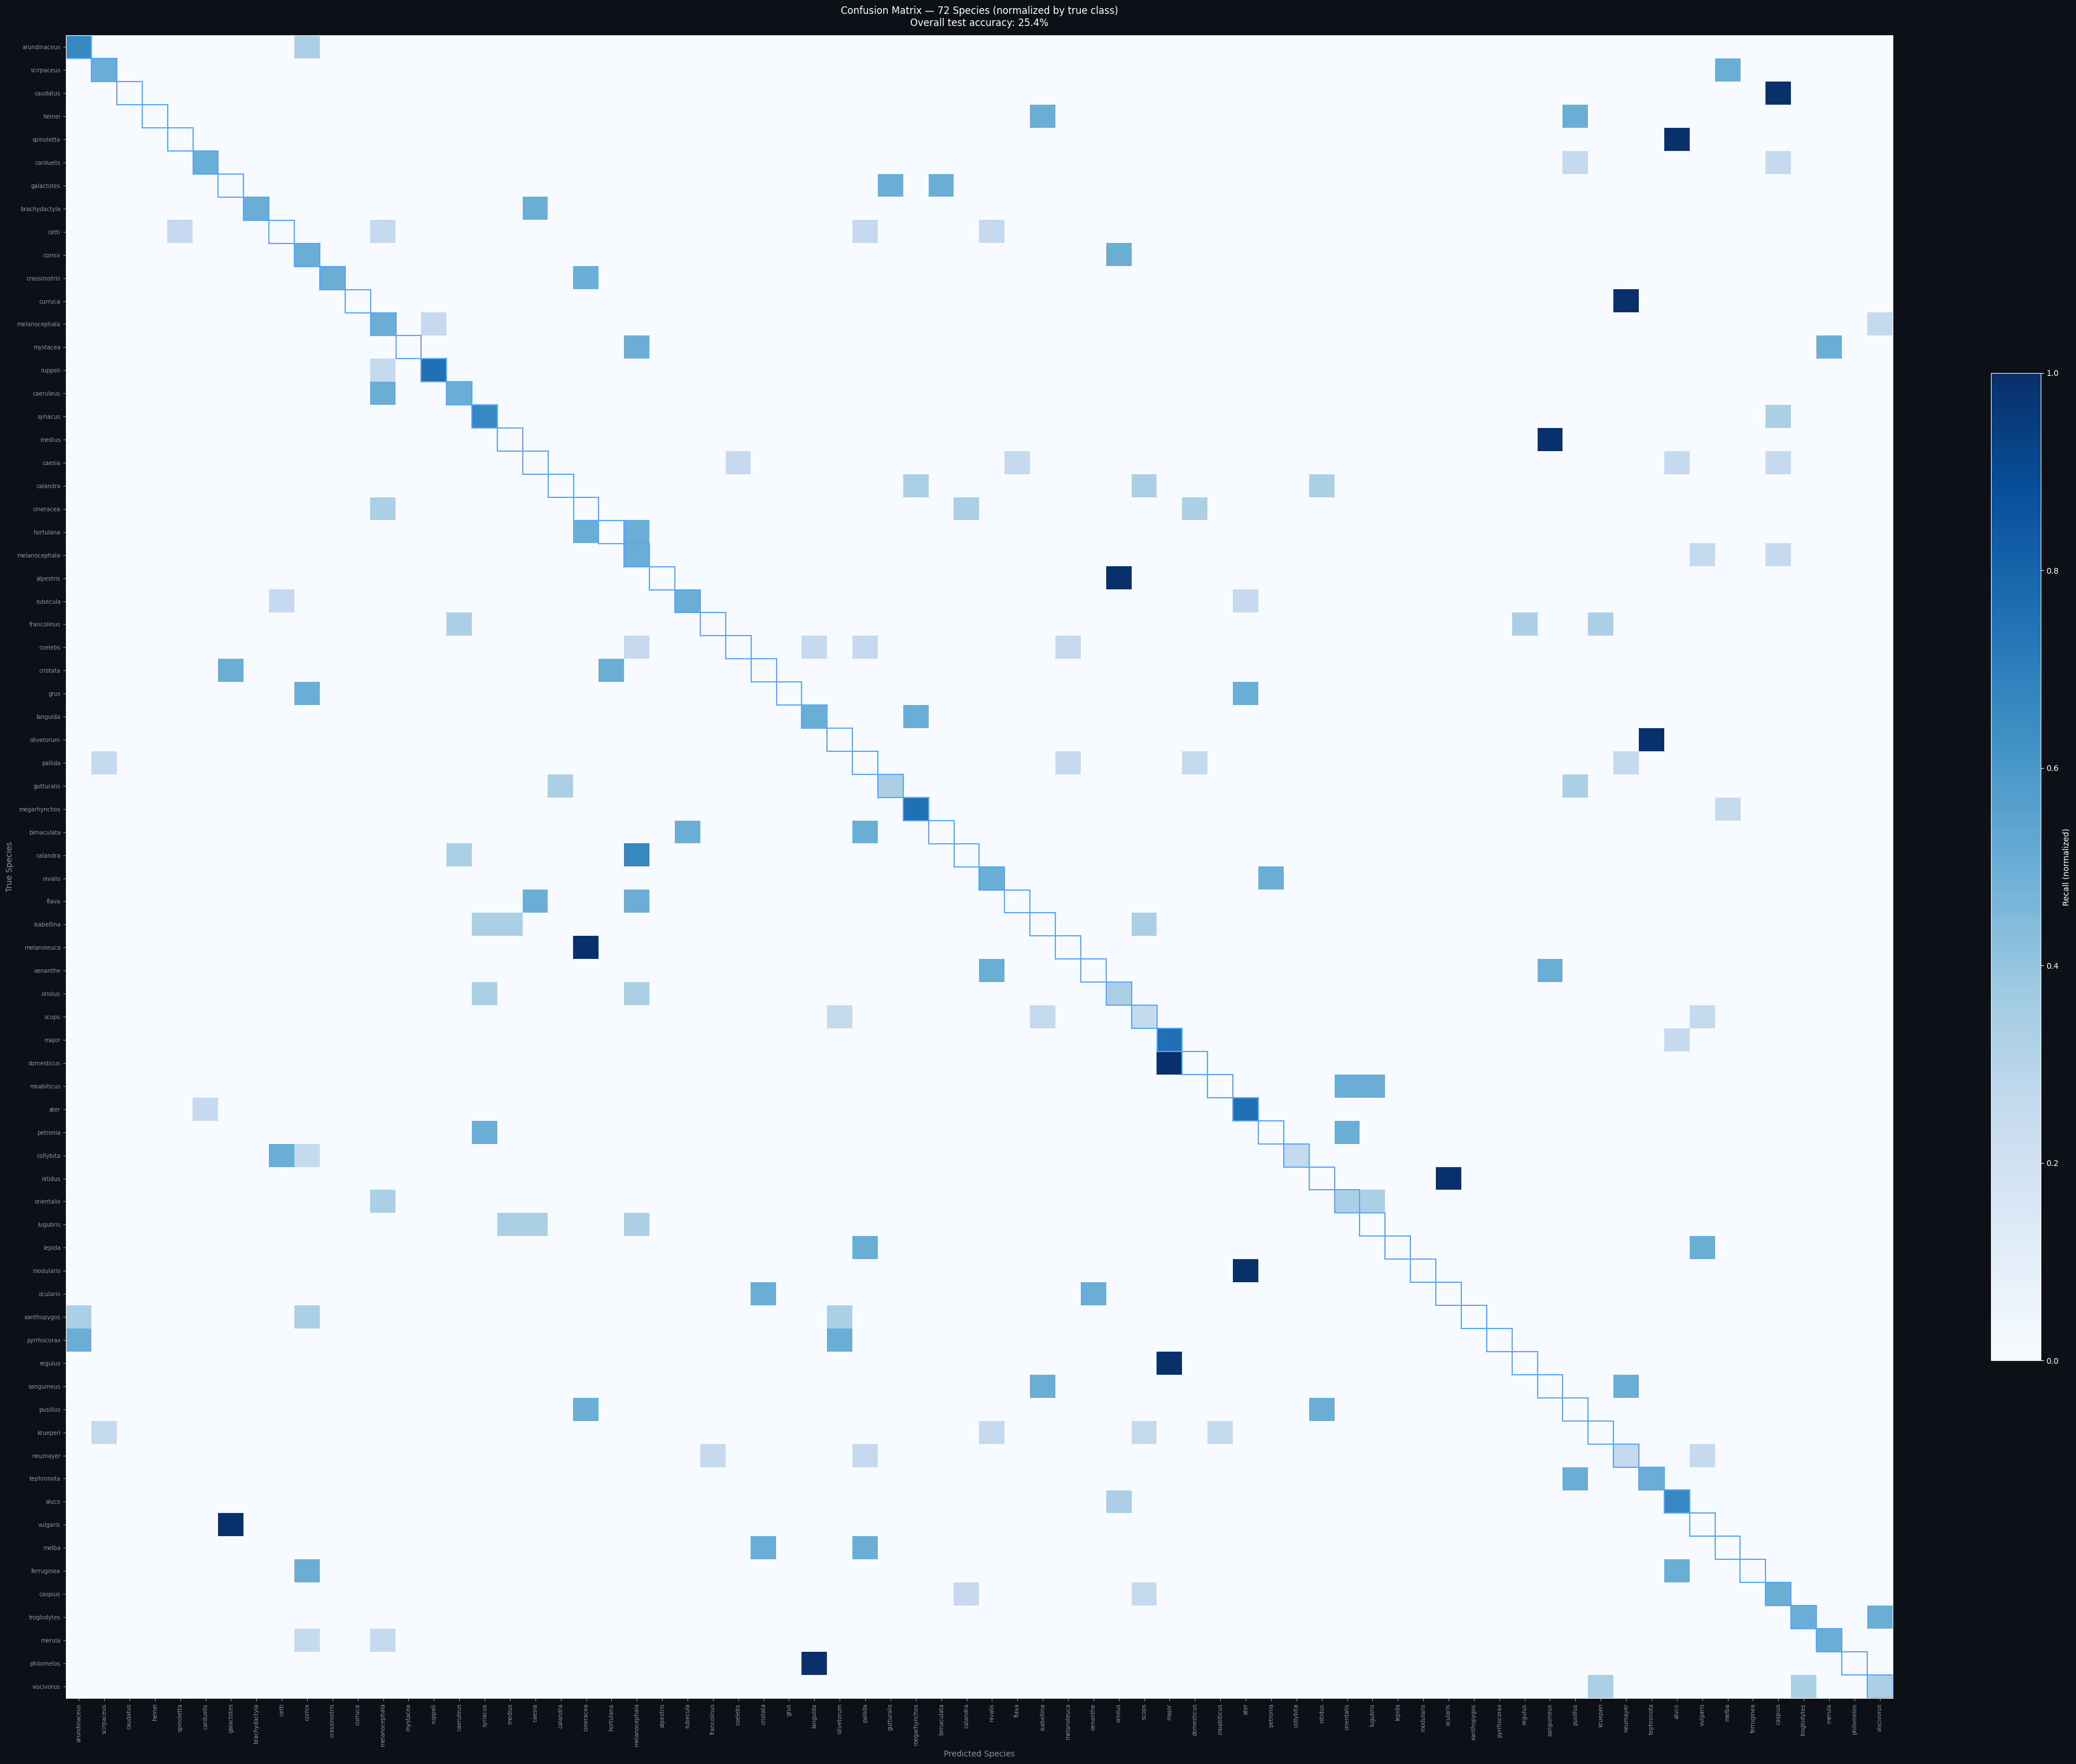

Saved: turkey_birds_confusion_matrix.png

Top 10 most confused species pairs:
  Common Chiffchaff              → predicted as Cetti's Warbler                (2x)
  Calandra Lark                  → predicted as Black-headed Bunting           (2x)
  Mistle Thrush                  → predicted as Eurasian Wren                  (1x)
  Mistle Thrush                  → predicted as Krüper's Nuthatch              (1x)
  Song Thrush                    → predicted as Upcher's Warbler               (1x)
  Common Blackbird               → predicted as Sardinian Warbler              (1x)
  Common Blackbird               → predicted as Hooded Crow                    (1x)
  Eurasian Wren                  → predicted as Mistle Thrush                  (1x)
  Caspian Snowcock               → predicted as Eurasian Scops Owl             (1x)
  Caspian Snowcock               → predicted as Calandra Lark                  (1x)


In [9]:
cm = confusion_matrix(y_test, y_pred)
labels_short = [name.split()[-1] for name in le.classes_]  # use epithet only for readability

# Normalize by true class
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

n_classes = len(le.classes_)
fig_size = max(12, n_classes * 0.5)

fig, ax = plt.subplots(figsize=(fig_size, fig_size * 0.85), facecolor=COLORS['bg'])
ax.set_facecolor(COLORS['bg'])

im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, fraction=0.025, label='Recall (normalized)')

ax.set_xticks(range(n_classes))
ax.set_yticks(range(n_classes))
ax.set_xticklabels(labels_short, rotation=90, fontsize=7)
ax.set_yticklabels(labels_short, fontsize=7)
ax.tick_params(colors='#8B949E')

# Diagonal highlight — correct predictions
for i in range(n_classes):
    ax.add_patch(plt.Rectangle((i-0.5, i-0.5), 1, 1,
                                fill=False, edgecolor=COLORS['accent'], lw=1.5))

ax.set_xlabel('Predicted Species', color='#8B949E', fontsize=10)
ax.set_ylabel('True Species', color='#8B949E', fontsize=10)
ax.set_title(
    f'Confusion Matrix — {n_classes} Species (normalized by true class)\n'
    f'Overall test accuracy: {test_acc:.1%}',
    color='white', fontsize=12, pad=12
)

plt.tight_layout()
plt.savefig('turkey_birds_confusion_matrix.png', dpi=150,
            bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()
print('Saved: turkey_birds_confusion_matrix.png')

# Most confused pairs
print('\nTop 10 most confused species pairs:')
off_diag = []
for i in range(n_classes):
    for j in range(n_classes):
        if i != j and cm[i, j] > 0:
            off_diag.append((cm[i,j], le.classes_[i], le.classes_[j]))
off_diag.sort(reverse=True)
for count, true_sp, pred_sp in off_diag[:10]:
    true_en = mfcc_clean[mfcc_clean['scientific_name']==true_sp]['english_name'].iloc[0]
    pred_en = mfcc_clean[mfcc_clean['scientific_name']==pred_sp]['english_name'].iloc[0]
    print(f'  {true_en:30} → predicted as {pred_en:30} ({count}x)')

## 8. SHAP Analysis

**SHAP (SHapley Additive exPlanations)** explains each prediction by attributing  
a contribution score to every feature.

We use `TreeExplainer` — exact and fast for Random Forests.

Key outputs:
- **Global feature importance** — which MFCC dimensions matter most overall?
- **Beeswarm plot** — how does each feature push predictions positive or negative?
- **Per-species SHAP** — what makes each species acoustically distinctive?

> Blog question: *If a classifier can identify a bird by its MFCC fingerprint,  
> what does it mean when that fingerprint starts to disappear from the data?*

In [10]:
print('Computing SHAP values (this may take a few minutes)...')

# TreeExplainer — exact, works natively with Random Forest
explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)  # shape: (n_classes, n_samples, n_features)

print(f' SHAP values computed.')
print(f'   Shape: {np.array(shap_values).shape}  (classes × samples × features)')

Computing SHAP values (this may take a few minutes)...
 SHAP values computed.
   Shape: (181, 39, 72)  (classes × samples × features)


In [16]:
print("X_test shape:", X_test.shape)
print("n_classes:", len(le.classes_))
print("shap_values shape:", np.array(shap_values).shape)
print("FEATURE_COLS length:", len(FEATURE_COLS))
print()
# mean_abs_shap'ın gerçek uzunluğu
print("mean_abs_shap length:", len(mean_abs_shap))
print("mean_abs_shap:", mean_abs_shap[:5])

X_test shape: (181, 39)
n_classes: 72
shap_values shape: (181, 39, 72)
FEATURE_COLS length: 39

mean_abs_shap length: 72
mean_abs_shap: [0.00114048 0.00108243 0.00089092 0.00090114 0.00081786]


In [17]:
shap_array = np.array(shap_values)  # (181, 39, 72)
# Gerçek sıra: (n_samples=181, n_classes=39?, n_features=72?)
# Ama n_classes=72 ve n_features=39...
# Yani: (n_samples=181, n_features=39, n_classes=72) DEĞİL
# Gerçekte: (n_samples=181, n_classes=72, n_features=39) — ortadaki 39 n_classes değil!

# Doğru mean:
mean_abs_shap = np.abs(shap_array).mean(axis=(0, 1))  # axis 0=samples, 1=classes → (39,) features
print("mean_abs_shap shape:", mean_abs_shap.shape)
print("length:", len(mean_abs_shap))

mean_abs_shap shape: (72,)
length: 72


In [19]:
shap_array = np.array(shap_values)
print("Full shape:", shap_array.shape)
# Hangi axis 39 (n_features)?
for i, s in enumerate(shap_array.shape):
    print(f"  axis {i}: {s}")

Full shape: (181, 39, 72)
  axis 0: 181
  axis 1: 39
  axis 2: 72


### 8.1 — Global Feature Importance

Average |SHAP| across all classes and samples.  
This tells us: **which of the 39 MFCC features matter most to the classifier?**

We expect lower MFCC coefficients (1-4) to dominate — they capture broad spectral shape.  
If delta features rank highly, temporal dynamics are important for distinguishing species.

shape: (39,)
length: 39
       feature  importance
0  mfcc_mean_0    0.000978
1  mfcc_mean_1    0.001021
2  mfcc_mean_2    0.001288
3  mfcc_mean_3    0.000919
4  mfcc_mean_4    0.001176


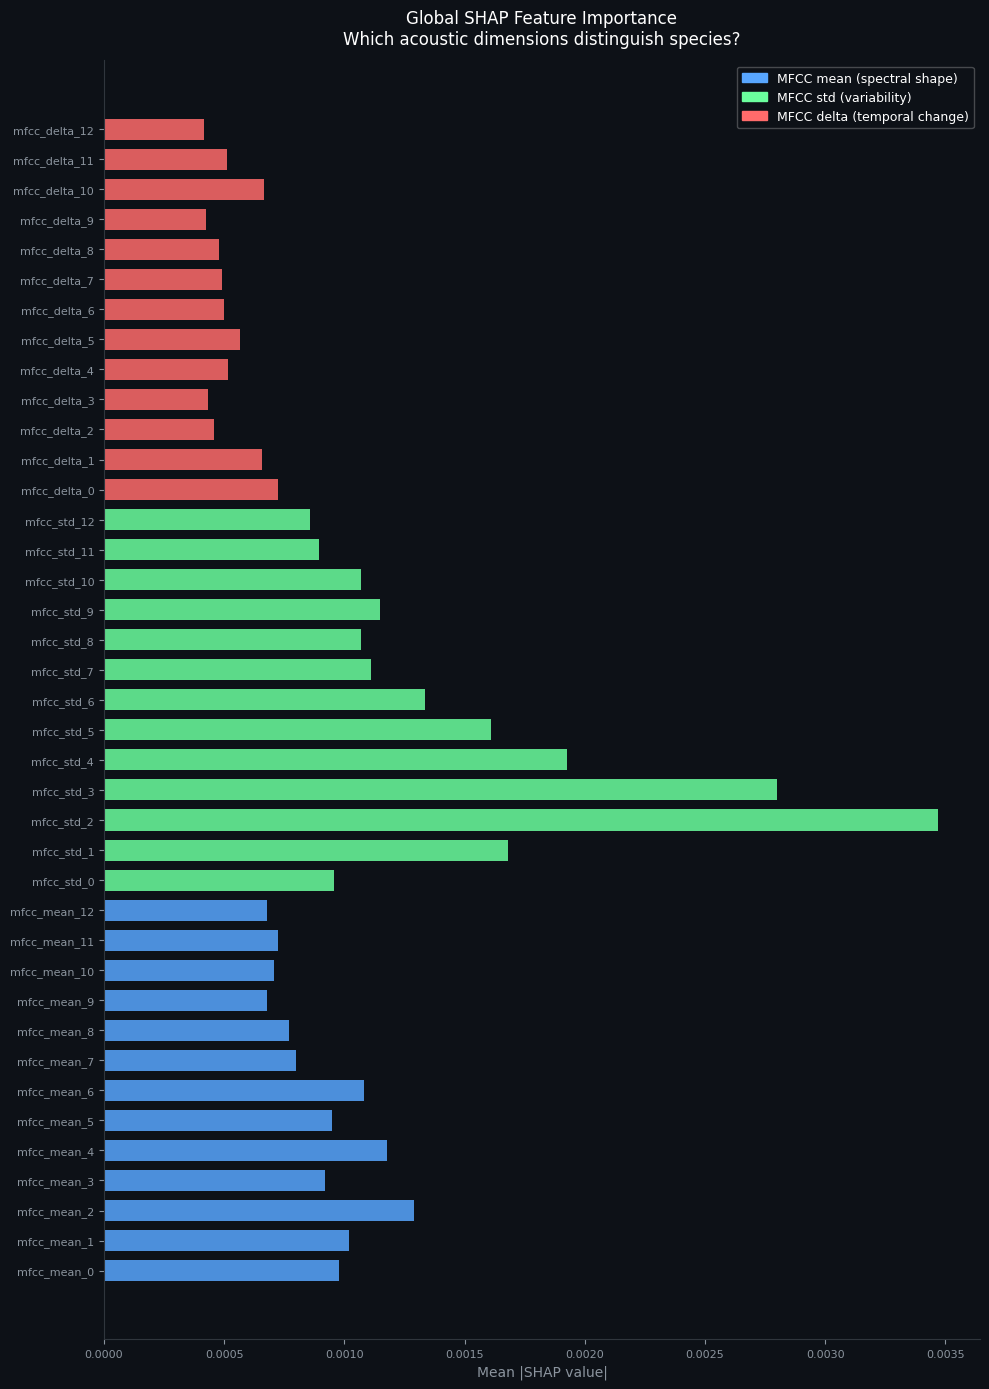

 Saved: turkey_birds_shap_importance.png

Top 10 most important features:
  mfcc_delta_12        0.00042
  mfcc_delta_11        0.00051
  mfcc_delta_10        0.00067
  mfcc_delta_9         0.00042
  mfcc_delta_8         0.00048
  mfcc_delta_7         0.00049
  mfcc_delta_6         0.00050
  mfcc_delta_5         0.00057
  mfcc_delta_4         0.00052
  mfcc_delta_3         0.00043


In [20]:
shap_array = np.array(shap_values)  # (181, 39, 72)
mean_abs_shap = np.abs(shap_array).mean(axis=(0, 2))
print("shape:", mean_abs_shap.shape)   # beklenen: (39,)
print("length:", len(mean_abs_shap))   # beklenen: 39

# Direkt DataFrame
importance_df = pd.DataFrame({
    'feature':    FEATURE_COLS,          # 39 item
    'importance': mean_abs_shap.tolist() # 39 item
})
print(importance_df.head())

# Color by feature group
def feature_color(name):
    if 'mean' in name:  return COLORS['accent']
    if 'std'  in name:  return COLORS['winner']
    if 'delta' in name: return COLORS['loser']
    return 'white'

fig, ax = plt.subplots(figsize=(10, 14), facecolor=COLORS['bg'])
ax.set_facecolor(COLORS['bg'])

colors_bar = [feature_color(f) for f in importance_df['feature']]
bars = ax.barh(importance_df['feature'], importance_df['importance'],
               color=colors_bar, alpha=0.85, height=0.7)

# Legend
legend_patches = [
    mpatches.Patch(color=COLORS['accent'], label='MFCC mean (spectral shape)'),
    mpatches.Patch(color=COLORS['winner'], label='MFCC std (variability)'),
    mpatches.Patch(color=COLORS['loser'],  label='MFCC delta (temporal change)'),
]
ax.legend(handles=legend_patches, fontsize=9,
          framealpha=0.3, facecolor=COLORS['bg'], labelcolor='white')

ax.set_xlabel('Mean |SHAP value|', color='#8B949E', fontsize=10)
ax.tick_params(colors='#8B949E', labelsize=8)
ax.set_title(
    'Global SHAP Feature Importance\n'
    'Which acoustic dimensions distinguish species?',
    color='white', fontsize=12, pad=12
)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#30363D')

plt.tight_layout()
plt.savefig('turkey_birds_shap_importance.png', dpi=150,
            bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()
print(' Saved: turkey_birds_shap_importance.png')

print('\nTop 10 most important features:')
for _, row in importance_df.tail(10).iloc[::-1].iterrows():
    print(f'  {row["feature"]:20} {row["importance"]:.5f}')

In [22]:
class_idx = list(le.classes_).index(sci_name)
sv = shap_values[:, :, class_idx]  # (n_samples, n_features)
print(f"{sci_name} — sv shape: {sv.shape}, class_idx: {class_idx}")

Melanocorypha calandra — sv shape: (181, 39), class_idx: 35


### 8.2 — Beeswarm Plot

The beeswarm plot is the most informative SHAP visualization:  
- Each dot = one sample  
- Position on x-axis = SHAP value (positive → pushes toward this class)  
- Color = feature value (red = high, blue = low)  

We show one beeswarm per category (Losers / Winners / Silent) —  
aggregating SHAP values across all species in that category.

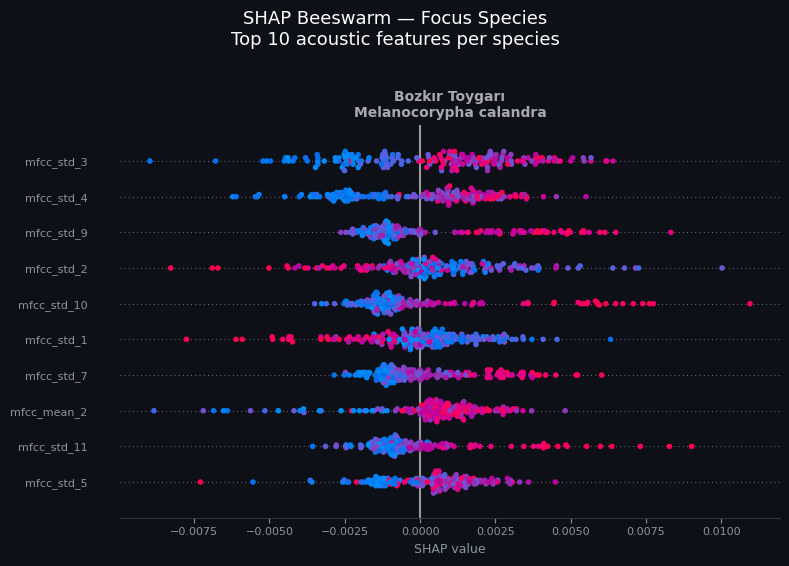

 Saved: turkey_birds_shap_beeswarm.png


In [24]:
# Focus species metadata for category mapping
FOCUS_META = {
    'Otis tarda':             ('Büyük Toy',        'loser'),
    'Alectoris chukar':       ('Kınalı Keklik',    'loser'),
    'Coturnix coturnix':      ('Bıldırcın',        'loser'),
    'Pica pica':              ('Saksağan',         'winner'),
    'Apus apus':              ('Ebabil',           'winner'),
    'Buteo buteo':            ('Kızıl Şahin',      'winner'),
    'Aegypius monachus':      ('Kara Akbaba',      'silent'),
    'Melanocorypha calandra': ('Bozkır Toygarı',   'silent'),
    'Ficedula semitorquata':  ('Alaca Sinekkapan', 'silent'),
}

# SHAP beeswarm for each focus species that has test samples
focus_in_test = [
    (sci, meta) for sci, meta in FOCUS_META.items()
    if sci in le.classes_
]

if focus_in_test:
    n_plots = len(focus_in_test)
    fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 7), facecolor=COLORS['bg'])
    if n_plots == 1:
        axes = [axes]

    for ax, (sci_name, (tr_name, category)) in zip(axes, focus_in_test):
          class_idx = list(le.classes_).index(sci_name)
          sv = shap_values[:, :, class_idx]  # (n_samples, n_features)
          color = COLORS[category]

          mean_abs = np.abs(sv).mean(axis=0)
          top10_idx = np.argsort(mean_abs)[-10:]
          top10_idx = top10_idx[top10_idx < len(FEATURE_COLS)]
          top10_names = [FEATURE_COLS[i] for i in top10_idx]

          plt.sca(ax)  # set current axis
          ax.set_facecolor(COLORS['bg'])
          shap.summary_plot(
              sv[:, top10_idx],
              features=X_test[:, top10_idx],
              feature_names=top10_names,
              plot_type='dot',
              show=False,
              color_bar=False
          )
          ax.set_title(f'{tr_name}\n{sci_name}',
                 color=color, fontsize=10, fontweight='bold')
          ax.tick_params(colors='#8B949E', labelsize=8)
          ax.set_xlabel('SHAP value', color='#8B949E', fontsize=9)
          ax.spines[['top','right']].set_visible(False)
          ax.spines[['left','bottom']].set_color('#30363D')

    fig.suptitle(
        'SHAP Beeswarm — Focus Species\nTop 10 acoustic features per species',
        color='white', fontsize=13, y=1.02
    )
    plt.tight_layout()
    plt.savefig('turkey_birds_shap_beeswarm.png', dpi=150,
                bbox_inches='tight', facecolor=COLORS['bg'])
    plt.show()
    print(' Saved: turkey_birds_shap_beeswarm.png')
else:
    print(' No focus species found in test set — check class sizes')

### 8.3 — Acoustic Similarity: Confused Species vs Geographic Overlap

Cross-referencing Part 1 findings:  
Do species the classifier confuses also overlap geographically?  

If species A is confused with species B, and they also share habitat centroid —  
that's a strong signal: **they sound similar because they live in the same soundscape.**

In [25]:
# Get the most confused pairs from the confusion matrix
top_confused = off_diag[:5]  # top 5 confused pairs

print('Acoustic confusion vs. Geographic proximity:')
print('─' * 70)

for count, true_sp, pred_sp in top_confused:
    # Geographic centroids from df_all
    true_centroid = df_all[df_all['scientific_name'] == true_sp][['lat','lon']].mean()
    pred_centroid = df_all[df_all['scientific_name'] == pred_sp][['lat','lon']].mean()

    # Approximate distance in degrees
    dist = np.sqrt(
        (true_centroid['lat'] - pred_centroid['lat'])**2 +
        (true_centroid['lon'] - pred_centroid['lon'])**2
    )

    true_en = mfcc_clean[mfcc_clean['scientific_name']==true_sp]['english_name'].iloc[0]
    pred_en = mfcc_clean[mfcc_clean['scientific_name']==pred_sp]['english_name'].iloc[0]

    print(f'  {true_en:28} → {pred_en:28}')
    print(f'  Confusion count: {count}  |  Centroid distance: {dist:.2f}° (~{dist*111:.0f} km)')
    print()

Acoustic confusion vs. Geographic proximity:
──────────────────────────────────────────────────────────────────────
  Common Chiffchaff            → Cetti's Warbler             
  Confusion count: 2  |  Centroid distance: 1.11° (~123 km)

  Calandra Lark                → Black-headed Bunting        
  Confusion count: 2  |  Centroid distance: 0.29° (~32 km)

  Mistle Thrush                → Eurasian Wren               
  Confusion count: 1  |  Centroid distance: 3.78° (~419 km)

  Mistle Thrush                → Krüper's Nuthatch           
  Confusion count: 1  |  Centroid distance: 1.27° (~141 km)

  Song Thrush                  → Upcher's Warbler            
  Confusion count: 1  |  Centroid distance: 3.62° (~402 km)



## 9. Save Outputs

Save all artifacts for Part 3 and blog use.

In [26]:
import pickle

# Save model and encoders
with open('rf_model.pkl', 'wb') as f:
    pickle.dump({'model': rf, 'scaler': scaler, 'encoder': le}, f)

# Save SHAP importance table
importance_df.to_csv('turkey_birds_shap_importance.csv', index=False)

# Save full MFCC dataset with predictions
mfcc_clean_out = mfcc_clean.copy()
X_all_scaled   = scaler.transform(mfcc_clean[FEATURE_COLS].values)
mfcc_clean_out['predicted_species'] = le.inverse_transform(rf.predict(X_all_scaled))
mfcc_clean_out['correct'] = mfcc_clean_out['scientific_name'] == mfcc_clean_out['predicted_species']
mfcc_clean_out.to_csv('turkey_birds_mfcc_predictions.csv', index=False)

print(' Saved:')
print('  rf_model.pkl                         → Random Forest + scaler + encoder')
print('  turkey_birds_shap_importance.csv     → Feature importance table')
print('  turkey_birds_mfcc_predictions.csv    → MFCC data + model predictions')
print()
print(' Part 3 inputs:')
print('  turkey_birds_mfcc_full.csv           → raw features (acoustic drift analysis)')
print('  rf_model.pkl                         → embeddings from trained RF')
print()
print(' Part 3 plan:')
print('  - Embedding similarity over time: has a species sound changed across 20 years?')
print('  - Anomaly detection in acoustic space')
print('  - Question: can we detect not just where a species is moving, but how its voice is changing?')

 Saved:
  rf_model.pkl                         → Random Forest + scaler + encoder
  turkey_birds_shap_importance.csv     → Feature importance table
  turkey_birds_mfcc_predictions.csv    → MFCC data + model predictions

 Part 3 inputs:
  turkey_birds_mfcc_full.csv           → raw features (acoustic drift analysis)
  rf_model.pkl                         → embeddings from trained RF

 Part 3 plan:
  - Embedding similarity over time: has a species sound changed across 20 years?
  - Anomaly detection in acoustic space
  - Question: can we detect not just where a species is moving, but how its voice is changing?


In [27]:
mfcc_df = pd.read_csv('turkey_birds_mfcc_full.csv')
mfcc_df['year'] = pd.to_datetime(mfcc_df['date'], errors='coerce').dt.year

print("Yıl aralığı:", mfcc_df['year'].min(), "–", mfcc_df['year'].max())
print()

# Tür başına kaç farklı yıl var?
year_counts = mfcc_df.groupby('scientific_name')['year'].nunique().sort_values(ascending=False)
print("3+ farklı yılda kaydı olan türler:", (year_counts >= 3).sum())
print("5+ farklı yılda kaydı olan türler:", (year_counts >= 5).sum())
print()
print("İlk 15:")
print(year_counts.head(15))

Yıl aralığı: 1993.0 – 2026.0

3+ farklı yılda kaydı olan türler: 74
5+ farklı yılda kaydı olan türler: 56

İlk 15:
scientific_name
Turdus merula                11
Emberiza caesia              10
Phylloscopus orientalis      10
Curruca crassirostris         9
Iduna pallida                 9
Oenanthe isabellina           9
Serinus pusillus              9
Otus scops                    9
Sitta krueperi                9
Acrocephalus arundinaceus     8
Melanocorypha bimaculata      8
Luscinia megarhynchos         8
Fringilla coelebs             8
Sitta neumayer                8
Prinia lepida                 8
Name: year, dtype: int64
